# Revision of the predictions as per ARIMA

In [442]:
# This script is an overview of the predictions as per ARIMA model for exit_velo forecasting per player


import pandas as pd
import matplotlib.pyplot as plt
root = '/Users/mariaoros/Documents/Github-projects/2025/Miami-marlins-challenge/'
df_out = pd.read_csv(root+'3_Modeling/time_series/outputs/per_batter_2024_predictions.csv')

print(df_out.head())

   batter_id  last_season last_level target_level_2024  seasons_in_data  \
0          2         2023        AAA                AA                1   
1          2         2023        AAA               AAA                1   
2          2         2023        AAA               MLB                1   
3          6         2023        MLB                AA                5   
4          6         2023        MLB               AAA                5   

   total_observations  recent_performance                    method  \
0                 393           90.597836  fallback_last_plus_level   
1                 393           90.597836  fallback_last_plus_level   
2                 393           90.597836  fallback_last_plus_level   
3                1111           87.045037           ARIMAX(0, 0, 0)   
4                1111           87.045037           ARIMAX(0, 0, 0)   

       fit_mode  val_rmse  val_mae    val_aic  arima_order_p  arima_order_d  \
0  simple_arima       NaN      NaN  13.8507

In [443]:
df_out.columns

Index(['batter_id', 'last_season', 'last_level', 'target_level_2024',
       'seasons_in_data', 'total_observations', 'recent_performance', 'method',
       'fit_mode', 'val_rmse', 'val_mae', 'val_aic', 'arima_order_p',
       'arima_order_d', 'arima_order_q', 'forecast', 'lower_95', 'upper_95',
       'prediction_std'],
      dtype='object')

In [444]:
df_out[['val_mae','val_rmse']].replace([np.inf, -np.inf], np.nan).dropna().describe()


,val_mae,val_rmse
count,849.000000,849.000000
mean,4.470326,5.281780
std,7.645714,9.811155
min,0.105667,0.105667
25%,1.618927,1.912497
50%,2.558292,3.006275
75%,4.693940,5.217761
max,99.224472,126.868099


In [445]:
df_out.groupby(['target_level_2024','fit_mode']).count()

batter_id  last_season  last_level  \
target_level_2024 fit_mode                                           
AA                aic                 320          320         320   
                  cv                  283          283         283   
                  simple_arima         38           38          38   
AAA               aic                 320          320         320   
                  cv                  283          283         283   
                  simple_arima         38           38          38   
MLB               aic                 320          320         320   
                  cv                  283          283         283   
                  simple_arima         38           38          38   

                                seasons_in_data  total_observations  \
target_level_2024 fit_mode                                            
AA                aic                       320                 320   
                  cv                        283                 283   
                  simple_arima               38                  38   
AAA               aic                       320                 320   
                  cv                        283                 283   
                  simple_arima               38                  38   
MLB               aic                       320                 320   
                  cv                        283                 283   
                  simple_arima               38                  38   

                                recent_performance  method  val_rmse  val_mae  \
target_level_2024 fit_mode                                                      
AA                aic                          320     320         0        0   
                  cv                           283     283       283      283   
                  simple_arima                  38      38         0        0   
AAA               aic                          320     320         0        0   
                  cv                           283     283       283      283   
                  simple_arima                  38      38         0        0   
MLB               aic                          320     320         0        0   
                  cv                           283     283       283      283   
                  simple_arima                  38      38         0        0   

                                val_aic  arima_order_p  arima_order_d  \
target_level_2024 fit_mode                                              
AA                aic               320            320            320   
                  cv                283            283            283   
                  simple_arima       38              0              0   
AAA               aic               320            320            320   
                  cv                283            283            283   
                  simple_arima       38              0              0   
MLB               aic               320            320            320   
                  cv                283            283            283   
                  simple_arima       38              0              0   

                                arima_order_q  forecast  lower_95  upper_95  \
target_level_2024 fit_mode                                                    
AA                aic                     320       320       320       320   
                  cv                      283       283       283       283   
                  simple_arima              0        38         0         0   
AAA               aic                     320       320       320       320   
                  cv                      283       283       283       283   
                  simple_arima              0        38         0         0   
MLB               aic                     320       320       320       320   
                  cv                      283       283       283       

In [446]:
df_out[df_out['target_level_2024']=='MLB']


,batter_id,last_season,last_level,target_level_2024,seasons_in_data,total_observations,recent_performance,method,fit_mode,val_rmse,val_mae,val_aic,arima_order_p,arima_order_d,arima_order_q,forecast,lower_95,upper_95,prediction_std
2,2,2023,AAA,MLB,1,393,90.597836,fallback_last_plus_level,simple_arima,NaN,NaN,13.850738,NaN,NaN,NaN,93.097836,NaN,NaN,NaN
5,6,2023,MLB,MLB,5,1111,87.045037,"ARIMAX(0, 0, 0)",aic,NaN,NaN,-89.702447,0.0,0.0,0.0,85.815989,85.815981,85.815997,0.000004
8,9,2023,AA,MLB,2,228,90.565194,"ARIMAX(0, 0, 0)",aic,NaN,NaN,-31.081812,0.0,0.0,0.0,90.565189,90.565181,90.565197,0.000004
11,11,2023,AAA,MLB,3,972,88.932086,"ARIMAX(0, 0, 0)",aic,NaN,NaN,-46.379426,0.0,0.0,0.0,84.749307,84.749297,84.749317,0.000005
14,12,2023,MLB,MLB,5,1740,88.392553,"ARIMAX(0, 0, 0)",cv,2.988415,2.277668,-37.965561,0.0,0.0,0.0,89.142990,89.142982,89.142998,0.000004
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1910,4088,2023,AAA,MLB,3,717,89.273595,"ARIMAX(0, 0, 0)",aic,NaN,NaN,-49.853583,0.0,0.0,0.0,90.018450,90.018439,90.018460,0.000005
1913,4097,2023,MLB,MLB,5,906,89.212297,"ARIMAX(0, 0, 0)",cv,29.522135,21.323778,-40.739522,0.0,0.0,0.0,85.935189,85.935181,85.935197,0.000004
1916,4099,2023,MLB,MLB,3,1005,91.735054,"ARIMAX(0, 0, 0)",aic,NaN,NaN,-48.492575,0.0,0.0,0.0,91.154796,91.154788,91.154804,0.000004
1919,4109,2023,AAA,MLB,5,1000,89.914423,"ARIMAX(0, 0, 0)",cv,2.271096,2.004932,-36.634250,0.0,0.0,0.0,77.151477,77.151468,77.151487,0.000005


In [447]:
df_out['forecast'].describe()

count    1923.000000
mean       88.530441
std        64.131827
min     -1661.973739
25%        85.364360
50%        88.530746
75%        91.324485
max      1673.895770
Name: forecast, dtype: float64

<Axes: >

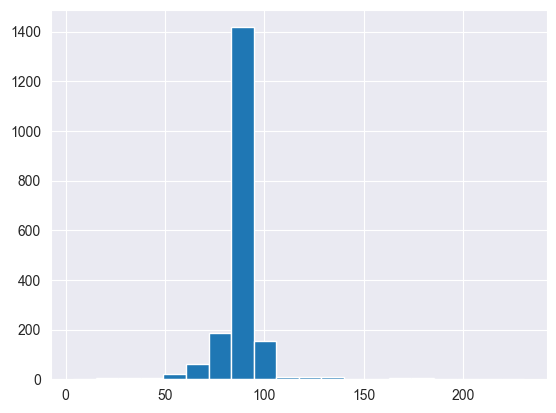

In [450]:
df_out[df_out['forecast'].between(0,250)]['forecast'].hist(bins=20)

In [451]:
df_out[df_out['forecast']<0] # 12 players with negatibve exit_velo

,batter_id,last_season,last_level,target_level_2024,seasons_in_data,total_observations,recent_performance,method,fit_mode,val_rmse,val_mae,val_aic,arima_order_p,arima_order_d,arima_order_q,forecast,lower_95,upper_95,prediction_std
420,843,2023,MLB,AA,5,1832,89.621468,"ARIMAX(0, 0, 0)",cv,2.336047,2.200750,-36.020421,0.0,0.0,0.0,-68.274503,-68.274510,-68.274495,0.000004
421,843,2023,MLB,AAA,5,1832,89.621468,"ARIMAX(0, 0, 0)",cv,2.336047,2.200750,-36.020421,0.0,0.0,0.0,-147.165859,-147.165866,-147.165851,0.000004
589,1260,2023,MLB,AAA,5,2034,85.246855,"ARIMAX(0, 0, 0)",cv,5.628184,4.732595,-35.795038,0.0,0.0,0.0,-16.896010,-16.896018,-16.896003,0.000004
1042,2339,2023,MLB,AAA,5,1604,91.384115,"ARIMAX(0, 0, 0)",cv,2.520969,2.322968,-37.694720,0.0,0.0,0.0,-1661.973739,-1661.973749,-1661.973729,0.000005
1072,2400,2023,AAA,AAA,5,1034,88.651239,"ARIMAX(0, 0, 0)",cv,3.071441,2.284230,-42.745837,0.0,0.0,0.0,-4.397639,-4.397648,-4.397629,0.000005
1108,2463,2023,MLB,AAA,5,1363,88.686657,"ARIMAX(0, 0, 0)",cv,7.606923,6.250558,-36.463175,0.0,0.0,0.0,-8.625386,-8.625394,-8.625378,0.000004
1186,2600,2023,MLB,AAA,5,1477,91.843629,"ARIMAX(0, 0, 0)",cv,4.355180,4.099360,-40.403085,0.0,0.0,0.0,-231.852908,-231.852916,-231.852900,0.000004
1546,3329,2023,MLB,AAA,5,1391,97.649865,"ARIMAX(0, 0, 0)",cv,3.006275,2.404756,-40.969935,0.0,0.0,0.0,-111.897982,-111.897990,-111.897974,0.000004
1548,3351,2023,MLB,AA,5,997,93.174810,"ARIMAX(0, 0, 0)",cv,5.173244,3.803479,-37.834919,0.0,0.0,0.0,-32.682779,-32.682787,-32.682771,0.000004
1693,3603,2023,MLB,AAA,5,1691,87.777151,"ARIMAX(0, 0, 0)",cv,1.638311,1.618927,-38.090906,0.0,0.0,0.0,-37.843119,-37.843127,-37.843112,0.000004


In [452]:
df_out.columns

Index(['batter_id', 'last_season', 'last_level', 'target_level_2024',
       'seasons_in_data', 'total_observations', 'recent_performance', 'method',
       'fit_mode', 'val_rmse', 'val_mae', 'val_aic', 'arima_order_p',
       'arima_order_d', 'arima_order_q', 'forecast', 'lower_95', 'upper_95',
       'prediction_std'],
      dtype='object')

In [453]:
df_out[df_out['val_rmse']!=np.inf][['val_rmse', 'val_mae', 'val_aic']].describe()

,val_rmse,val_mae,val_aic
count,849.000000,849.000000,1923.000000
mean,5.281780,4.470326,-43.248695
std,9.811155,7.645714,24.635919
min,0.105667,0.105667,-104.396967
25%,1.912497,1.618927,-47.563922
50%,3.006275,2.558292,-38.695262
75%,5.217761,4.693940,-36.025912
max,126.868099,99.224472,13.920897


In [454]:
df_out[df_out['val_rmse'].isna()].groupby(['method']).count()


,batter_id,last_season,last_level,target_level_2024,seasons_in_data,total_observations,recent_performance,fit_mode,val_rmse,val_mae,val_aic,arima_order_p,arima_order_d,arima_order_q,forecast,lower_95,upper_95,prediction_std
method,,,,,,,,,,,,,,,,,,
"ARIMAX(0, 0, 0)",951,951,951,951,951,951,951,951,0,0,951,951,951,951,951,951,951,951
"ARIMAX(0, 0, 1)",9,9,9,9,9,9,9,9,0,0,9,9,9,9,9,9,9,9
fallback_last_plus_level,114,114,114,114,114,114,114,114,0,0,114,0,0,0,114,0,0,0


In [455]:
df_out.columns

Index(['batter_id', 'last_season', 'last_level', 'target_level_2024',
       'seasons_in_data', 'total_observations', 'recent_performance', 'method',
       'fit_mode', 'val_rmse', 'val_mae', 'val_aic', 'arima_order_p',
       'arima_order_d', 'arima_order_q', 'forecast', 'lower_95', 'upper_95',
       'prediction_std'],
      dtype='object')

In [456]:
df_out.groupby(['method']).count()

,batter_id,last_season,last_level,target_level_2024,seasons_in_data,total_observations,recent_performance,fit_mode,val_rmse,val_mae,val_aic,arima_order_p,arima_order_d,arima_order_q,forecast,lower_95,upper_95,prediction_std
method,,,,,,,,,,,,,,,,,,
"ARIMAX(0, 0, 0)",1800,1800,1800,1800,1800,1800,1800,1800,849,849,1800,1800,1800,1800,1800,1800,1800,1800
"ARIMAX(0, 0, 1)",9,9,9,9,9,9,9,9,0,0,9,9,9,9,9,9,9,9
fallback_last_plus_level,114,114,114,114,114,114,114,114,0,0,114,0,0,0,114,0,0,0


In [457]:
df_out.groupby(['batter_id','last_season']).count()

,,last_level,target_level_2024,seasons_in_data,total_observations,recent_performance,method,fit_mode,val_rmse,val_mae,val_aic,arima_order_p,arima_order_d,arima_order_q,forecast,lower_95,upper_95,prediction_std
batter_id,last_season,,,,,,,,,,,,,,,,,
2,2023,3,3,3,3,3,3,3,0,0,3,0,0,0,3,0,0,0
6,2023,3,3,3,3,3,3,3,0,0,3,3,3,3,3,3,3,3
9,2023,3,3,3,3,3,3,3,0,0,3,3,3,3,3,3,3,3
11,2023,3,3,3,3,3,3,3,0,0,3,3,3,3,3,3,3,3
12,2023,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4088,2023,3,3,3,3,3,3,3,0,0,3,3,3,3,3,3,3,3
4097,2023,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3
4099,2023,3,3,3,3,3,3,3,0,0,3,3,3,3,3,3,3,3


In [458]:
!pwd

/Users/mariaoros/Documents/Github-projects/2025/Miami-marlins-challenge/3_Modeling/time_series


In [459]:
validate = pd.read_csv('/Users/mariaoros/Documents/Github-projects/2025/Miami-marlins-challenge/1_Data/exit_velo_validate_data.csv')
print(validate.head(5))

   season  batter_id   age
0    2024          2  25.4
1    2024          6  29.2
2    2024          9  22.3
3    2024         11  26.8
4    2024         12  34.8


In [460]:
len(validate), df_out.columns

(647,
 Index(['batter_id', 'last_season', 'last_level', 'target_level_2024',
        'seasons_in_data', 'total_observations', 'recent_performance', 'method',
        'fit_mode', 'val_rmse', 'val_mae', 'val_aic', 'arima_order_p',
        'arima_order_d', 'arima_order_q', 'forecast', 'lower_95', 'upper_95',
        'prediction_std'],
       dtype='object'))

In [461]:
df_out[df_out['target_level_2024']=='MLB']

,batter_id,last_season,last_level,target_level_2024,seasons_in_data,total_observations,recent_performance,method,fit_mode,val_rmse,val_mae,val_aic,arima_order_p,arima_order_d,arima_order_q,forecast,lower_95,upper_95,prediction_std
2,2,2023,AAA,MLB,1,393,90.597836,fallback_last_plus_level,simple_arima,NaN,NaN,13.850738,NaN,NaN,NaN,93.097836,NaN,NaN,NaN
5,6,2023,MLB,MLB,5,1111,87.045037,"ARIMAX(0, 0, 0)",aic,NaN,NaN,-89.702447,0.0,0.0,0.0,85.815989,85.815981,85.815997,0.000004
8,9,2023,AA,MLB,2,228,90.565194,"ARIMAX(0, 0, 0)",aic,NaN,NaN,-31.081812,0.0,0.0,0.0,90.565189,90.565181,90.565197,0.000004
11,11,2023,AAA,MLB,3,972,88.932086,"ARIMAX(0, 0, 0)",aic,NaN,NaN,-46.379426,0.0,0.0,0.0,84.749307,84.749297,84.749317,0.000005
14,12,2023,MLB,MLB,5,1740,88.392553,"ARIMAX(0, 0, 0)",cv,2.988415,2.277668,-37.965561,0.0,0.0,0.0,89.142990,89.142982,89.142998,0.000004
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1910,4088,2023,AAA,MLB,3,717,89.273595,"ARIMAX(0, 0, 0)",aic,NaN,NaN,-49.853583,0.0,0.0,0.0,90.018450,90.018439,90.018460,0.000005
1913,4097,2023,MLB,MLB,5,906,89.212297,"ARIMAX(0, 0, 0)",cv,29.522135,21.323778,-40.739522,0.0,0.0,0.0,85.935189,85.935181,85.935197,0.000004
1916,4099,2023,MLB,MLB,3,1005,91.735054,"ARIMAX(0, 0, 0)",aic,NaN,NaN,-48.492575,0.0,0.0,0.0,91.154796,91.154788,91.154804,0.000004
1919,4109,2023,AAA,MLB,5,1000,89.914423,"ARIMAX(0, 0, 0)",cv,2.271096,2.004932,-36.634250,0.0,0.0,0.0,77.151477,77.151468,77.151487,0.000005


In [462]:
merge_w_validate = validate.merge(df_out[df_out['target_level_2024']=='MLB'], on='batter_id', how='left')


print(len(merge_w_validate), len(validate), len(df_out[df_out['target_level_2024']=='MLB']))

647 647 641


In [463]:
len(merge_w_validate[merge_w_validate['forecast'].isna()])

6

In [464]:
# No prediction
merge_w_validate[merge_w_validate['forecast'].isna()]

,season,batter_id,age,last_season,last_level,target_level_2024,seasons_in_data,total_observations,recent_performance,method,...,val_rmse,val_mae,val_aic,arima_order_p,arima_order_d,arima_order_q,forecast,lower_95,upper_95,prediction_std
69,2024,390,23.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
159,2024,966,25.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
185,2024,1171,22.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
218,2024,1375,21.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
573,2024,3635,21.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
638,2024,4080,23.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [465]:
merge_w_validate[merge_w_validate['forecast'].isna()].batter_id.values

array([ 390,  966, 1171, 1375, 3635, 4080])

In [487]:
merge_w_validate

,season,batter_id,age,last_season,last_level,target_level_2024,seasons_in_data,total_observations,recent_performance,method,...,val_rmse,val_mae,val_aic,arima_order_p,arima_order_d,arima_order_q,forecast,lower_95,upper_95,prediction_std
0,2024,2,25.4,2023.0,AAA,MLB,1.0,393.0,90.597836,fallback_last_plus_level,...,NaN,NaN,13.850738,NaN,NaN,NaN,93.097836,NaN,NaN,NaN
1,2024,6,29.2,2023.0,MLB,MLB,5.0,1111.0,87.045037,"ARIMAX(0, 0, 0)",...,NaN,NaN,-89.702447,0.0,0.0,0.0,85.815989,85.815981,85.815997,0.000004
2,2024,9,22.3,2023.0,AA,MLB,2.0,228.0,90.565194,"ARIMAX(0, 0, 0)",...,NaN,NaN,-31.081812,0.0,0.0,0.0,90.565189,90.565181,90.565197,0.000004
3,2024,11,26.8,2023.0,AAA,MLB,3.0,972.0,88.932086,"ARIMAX(0, 0, 0)",...,NaN,NaN,-46.379426,0.0,0.0,0.0,84.749307,84.749297,84.749317,0.000005
4,2024,12,34.8,2023.0,MLB,MLB,5.0,1740.0,88.392553,"ARIMAX(0, 0, 0)",...,2.988415,2.277668,-37.965561,0.0,0.0,0.0,89.142990,89.142982,89.142998,0.000004
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
642,2024,4088,25.9,2023.0,AAA,MLB,3.0,717.0,89.273595,"ARIMAX(0, 0, 0)",...,NaN,NaN,-49.853583,0.0,0.0,0.0,90.018450,90.018439,90.018460,0.000005
643,2024,4097,26.6,2023.0,MLB,MLB,5.0,906.0,89.212297,"ARIMAX(0, 0, 0)",...,29.522135,21.323778,-40.739522,0.0,0.0,0.0,85.935189,85.935181,85.935197,0.000004
644,2024,4099,24.8,2023.0,MLB,MLB,3.0,1005.0,91.735054,"ARIMAX(0, 0, 0)",...,NaN,NaN,-48.492575,0.0,0.0,0.0,91.154796,91.154788,91.154804,0.000004
645,2024,4109,25.2,2023.0,AAA,MLB,5.0,1000.0,89.914423,"ARIMAX(0, 0, 0)",...,2.271096,2.004932,-36.634250,0.0,0.0,0.0,77.151477,77.151468,77.151487,0.000005


In [488]:
merge_w_validate.columns

Index(['season', 'batter_id', 'age', 'last_season', 'last_level',
       'target_level_2024', 'seasons_in_data', 'total_observations',
       'recent_performance', 'method', 'fit_mode', 'val_rmse', 'val_mae',
       'val_aic', 'arima_order_p', 'arima_order_d', 'arima_order_q',
       'forecast', 'lower_95', 'upper_95', 'prediction_std'],
      dtype='object')

In [489]:
merge_w_validate[['season', 'batter_id', 'age', 'last_season',
       'target_level_2024', 'seasons_in_data', 'total_observations',
       'recent_performance', 'method', 'fit_mode', 'val_rmse', 'val_mae',
       'val_aic', 'arima_order_p', 'arima_order_d', 'arima_order_q',
       'forecast', 'lower_95', 'upper_95', 'prediction_std']].to_csv("forecasting2024_mlb_maria.csv")

In [466]:
import seaborn as sns

<Axes: xlabel='age', ylabel='forecast'>

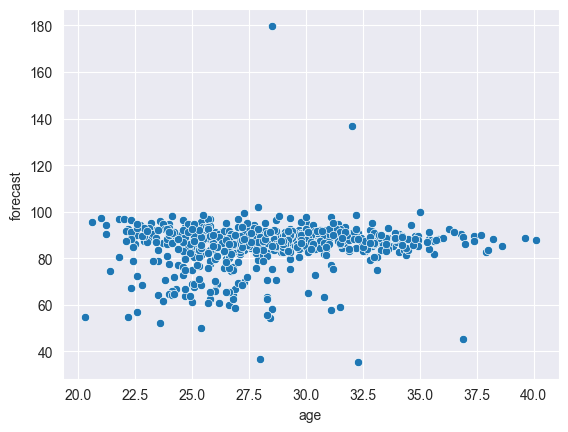

In [469]:
sns.scatterplot(data=merge_w_validate, x="age", y="forecast")

In [470]:
df = pd.read_csv('/Users/mariaoros/Documents/Github-projects/2025/Miami-marlins-challenge/1_Data/exit_velo_project_data.csv')

df_in = (
        df.groupby(['batter_id'])['exit_velo']
        .agg(['mean', 'count', 'std'])
        .reset_index()
    )
df_in.columns = ['batter_id', 'mean_exit_velo', 'count_events', 'std_exit_velo']

all_tog = merge_w_validate.merge(df_in, on='batter_id', how='left')


print(len(all_tog), len(merge_w_validate))

647 647


In [471]:
df[df['batter_id']==1171]


,season,level_abbr,batter_id,pitcher_id,exit_velo,launch_angle,spray_angle,hangtime,hit_type,batter_hand,pitcher_hand,batter_height,pitch_group,outcome,age


In [472]:
df[df['batter_id']==2086]

,season,level_abbr,batter_id,pitcher_id,exit_velo,launch_angle,spray_angle,hangtime,hit_type,batter_hand,pitcher_hand,batter_height,pitch_group,outcome,age
2223,2023,mlb,2086,3175,79.5156,-69.9285,19.8082,0.0177,ground_ball,R,R,70,FB,out,21.6
3593,2023,mlb,2086,3617,108.0728,29.3553,-29.3651,5.3937,fly_ball,R,L,70,FB,home_run,21.6
3601,2023,mlb,2086,3617,106.1553,28.9502,-21.8143,5.5463,fly_ball,R,L,70,FB,home_run,21.6
4686,2023,mlb,2086,4027,105.4672,36.4964,17.2823,6.0248,fly_ball,R,L,70,FB,out,21.6
4696,2023,mlb,2086,4027,82.5463,78.8131,-32.5807,6.1798,pop_up,R,L,70,OS,out,21.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1160811,2022,aa,2086,917,107.4956,26.3606,2.6422,5.0365,line_drive,R,R,70,FB,home_run,20.6
1161432,2022,aa,2086,1371,94.9537,71.2118,-17.3096,NaN,pop_up,R,R,70,FB,out,20.6
1161441,2022,aa,2086,1371,108.1892,22.1006,-4.3728,4.6157,fly_ball,R,R,70,BB,double,20.6
1161449,2022,aa,2086,1371,103.9765,26.4733,-12.9681,4.9781,fly_ball,R,R,70,FB,home_run,20.6


In [473]:
df[df['batter_id'].isin(merge_w_validate[merge_w_validate['forecast'].isna()].batter_id.values)].groupby(['batter_id'])['season'].nunique()

Series([], Name: season, dtype: int64)

In [474]:
df_out[df_out['batter_id']==2086]


,batter_id,last_season,last_level,target_level_2024,seasons_in_data,total_observations,recent_performance,method,fit_mode,val_rmse,val_mae,val_aic,arima_order_p,arima_order_d,arima_order_q,forecast,lower_95,upper_95,prediction_std
936,2086,2023,MLB,AA,2,526,90.219591,"ARIMAX(0, 0, 0)",aic,NaN,NaN,-27.744614,0.0,0.0,0.0,91.330920,91.330912,91.330927,0.000004
937,2086,2023,MLB,AAA,2,526,90.219591,"ARIMAX(0, 0, 0)",aic,NaN,NaN,-27.744614,0.0,0.0,0.0,92.894701,92.894694,92.894709,0.000004
938,2086,2023,MLB,MLB,2,526,90.219591,"ARIMAX(0, 0, 0)",aic,NaN,NaN,-27.744614,0.0,0.0,0.0,90.140616,90.140608,90.140624,0.000004


In [475]:
df[df['batter_id']==2086]

,season,level_abbr,batter_id,pitcher_id,exit_velo,launch_angle,spray_angle,hangtime,hit_type,batter_hand,pitcher_hand,batter_height,pitch_group,outcome,age
2223,2023,mlb,2086,3175,79.5156,-69.9285,19.8082,0.0177,ground_ball,R,R,70,FB,out,21.6
3593,2023,mlb,2086,3617,108.0728,29.3553,-29.3651,5.3937,fly_ball,R,L,70,FB,home_run,21.6
3601,2023,mlb,2086,3617,106.1553,28.9502,-21.8143,5.5463,fly_ball,R,L,70,FB,home_run,21.6
4686,2023,mlb,2086,4027,105.4672,36.4964,17.2823,6.0248,fly_ball,R,L,70,FB,out,21.6
4696,2023,mlb,2086,4027,82.5463,78.8131,-32.5807,6.1798,pop_up,R,L,70,OS,out,21.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1160811,2022,aa,2086,917,107.4956,26.3606,2.6422,5.0365,line_drive,R,R,70,FB,home_run,20.6
1161432,2022,aa,2086,1371,94.9537,71.2118,-17.3096,NaN,pop_up,R,R,70,FB,out,20.6
1161441,2022,aa,2086,1371,108.1892,22.1006,-4.3728,4.6157,fly_ball,R,R,70,BB,double,20.6
1161449,2022,aa,2086,1371,103.9765,26.4733,-12.9681,4.9781,fly_ball,R,R,70,FB,home_run,20.6


In [476]:
all_tog.columns

Index(['season', 'batter_id', 'age', 'last_season', 'last_level',
       'target_level_2024', 'seasons_in_data', 'total_observations',
       'recent_performance', 'method', 'fit_mode', 'val_rmse', 'val_mae',
       'val_aic', 'arima_order_p', 'arima_order_d', 'arima_order_q',
       'forecast', 'lower_95', 'upper_95', 'prediction_std', 'mean_exit_velo',
       'count_events', 'std_exit_velo'],
      dtype='object')

<Axes: xlabel='mean_exit_velo', ylabel='forecast'>

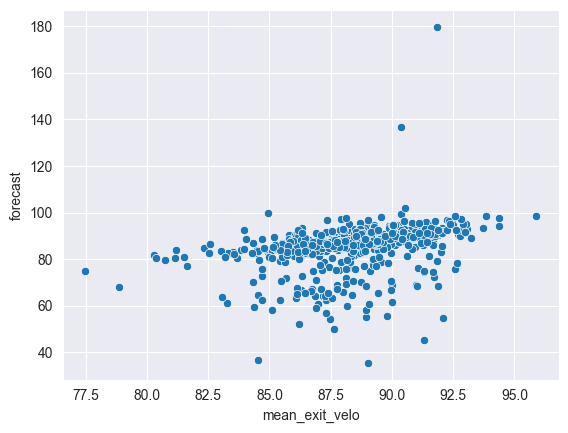

In [477]:
sns.scatterplot(data=all_tog, x="mean_exit_velo", y="forecast")


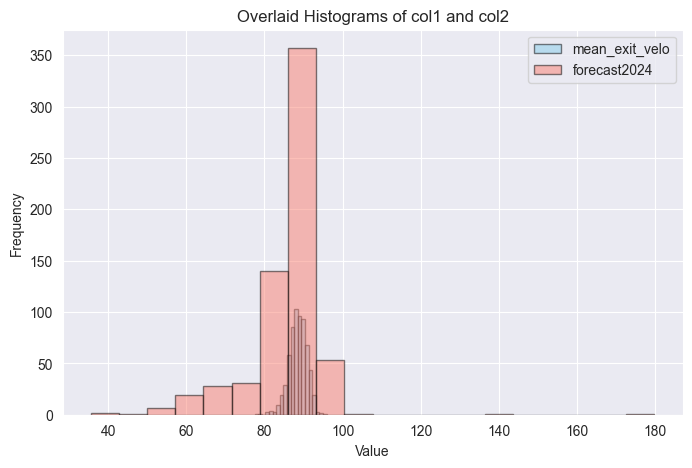

In [479]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
#data=all_tog, x="mean_exit_velo", y="predicted_exit_velo")
plt.hist(all_tog["mean_exit_velo"], bins=20, alpha=0.5, label="mean_exit_velo", color="skyblue", edgecolor="black")
plt.hist(all_tog["forecast"], bins=20, alpha=0.5, label="forecast2024", color="salmon", edgecolor="black")

plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Overlaid Histograms of col1 and col2")
plt.legend()
plt.show()


## Evaluation

In [480]:
#predictions
df_out = pd.read_csv(root+'3_Modeling/time_series/outputs/per_batter_2024_predictions.csv')
df_out = df_out[df_out['target_level_2024']=='MLB']#df_out[df_out['forecast']>0]
print(df_out.head())

    batter_id  last_season last_level target_level_2024  seasons_in_data  \
2           2         2023        AAA               MLB                1   
5           6         2023        MLB               MLB                5   
8           9         2023         AA               MLB                2   
11         11         2023        AAA               MLB                3   
14         12         2023        MLB               MLB                5   

    total_observations  recent_performance                    method  \
2                  393           90.597836  fallback_last_plus_level   
5                 1111           87.045037           ARIMAX(0, 0, 0)   
8                  228           90.565194           ARIMAX(0, 0, 0)   
11                 972           88.932086           ARIMAX(0, 0, 0)   
14                1740           88.392553           ARIMAX(0, 0, 0)   

        fit_mode  val_rmse   val_mae    val_aic  arima_order_p  arima_order_d  \
2   simple_arima       NaN   

In [481]:
df = pd.read_csv(root+'1_Data/exit_velo_project_data.csv')
df

,season,level_abbr,batter_id,pitcher_id,exit_velo,launch_angle,spray_angle,hangtime,hit_type,batter_hand,pitcher_hand,batter_height,pitch_group,outcome,age
0,2023,mlb,235,1335,95.7352,47.236200,-6.442200,6.4960,fly_ball,R,R,72,FB,out,32.8
1,2023,mlb,3182,1335,95.9380,4.729100,-4.805200,0.7806,ground_ball,L,R,75,OS,out,29.2
2,2023,mlb,3856,1988,89.1404,-16.225100,15.238200,0.0311,ground_ball,S,R,72,OS,out,29.7
3,2023,mlb,2017,1988,88.7278,-6.838500,-11.598800,0.1215,ground_ball,R,R,69,BB,out,23.4
4,2023,mlb,1594,1988,89.2888,0.507900,-22.189900,0.3802,ground_ball,R,R,73,FB,out,35.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1344646,2019,aa,1848,4151,101.8382,-13.584800,2.508200,0.0582,ground_ball,R,R,69,FB,out,23.7
1344647,2019,aa,994,2728,70.1142,0.194100,6.504300,0.3706,ground_ball,L,L,69,FB,out,24.7
1344648,2019,aa,3584,2728,NaN,53.934833,13.737205,NaN,pop_up,R,L,70,BB,out,24.8
1344649,2019,aa,326,4151,82.0584,12.637400,-23.095600,1.8708,line_drive,L,R,73,OS,single,23.1


In [482]:
df[df['batter_id'].isin([390, 966, 1171, 1375, 3635, 4080])] #no data for the batter ids without prediction

,season,level_abbr,batter_id,pitcher_id,exit_velo,launch_angle,spray_angle,hangtime,hit_type,batter_hand,pitcher_hand,batter_height,pitch_group,outcome,age


 ====================== TOP BATTERS 2725
single positional indexer is out-of-bounds
 ====================== TOP BATTERS 3329


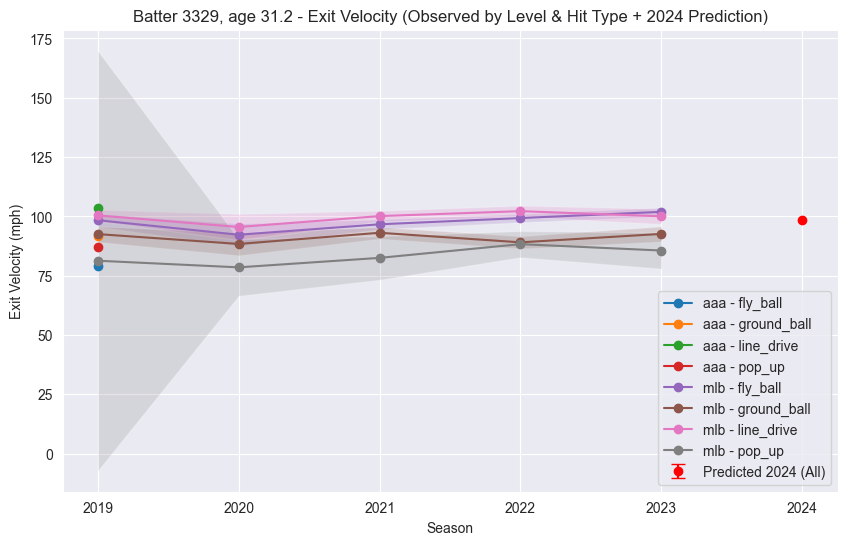

 ====================== TOP BATTERS 2441
single positional indexer is out-of-bounds
 ====================== TOP BATTERS 2334


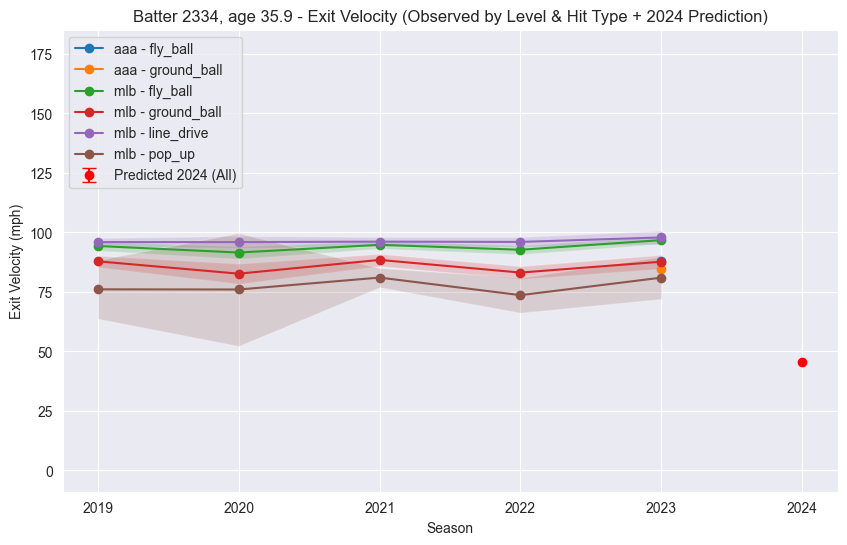

 ====================== Example BATTERS 2432
single positional indexer is out-of-bounds
 ====================== Example BATTERS 3814


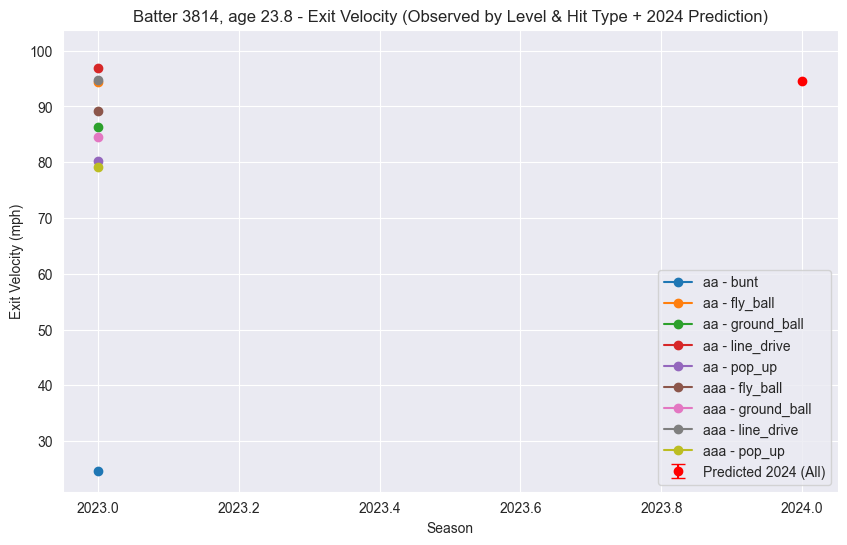

 ====================== Example BATTERS 3562
single positional indexer is out-of-bounds
 ====================== Example BATTERS 798
single positional indexer is out-of-bounds
 ====================== Example BATTERS 3798
single positional indexer is out-of-bounds
 ====================== Low ELO score BATTERS 1685
single positional indexer is out-of-bounds
 ====================== Low ELO score BATTERS 3590


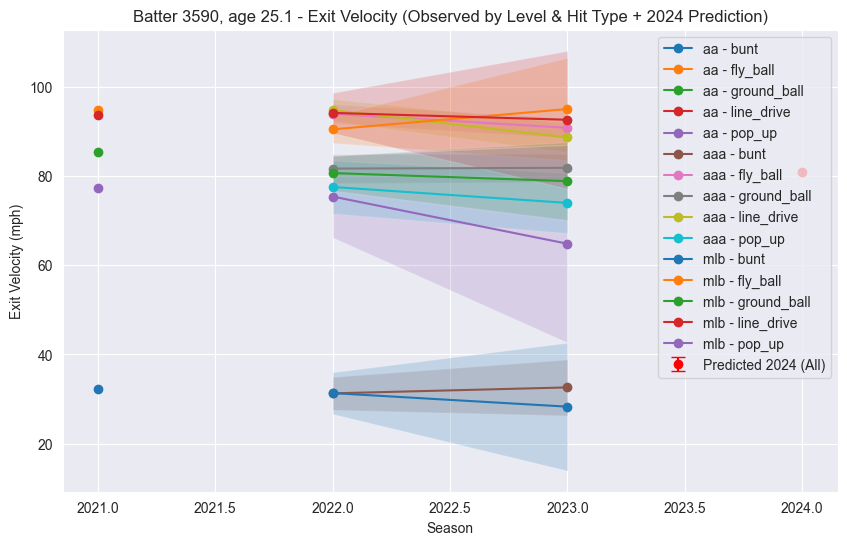

 ====================== Low ELO score BATTERS 3558


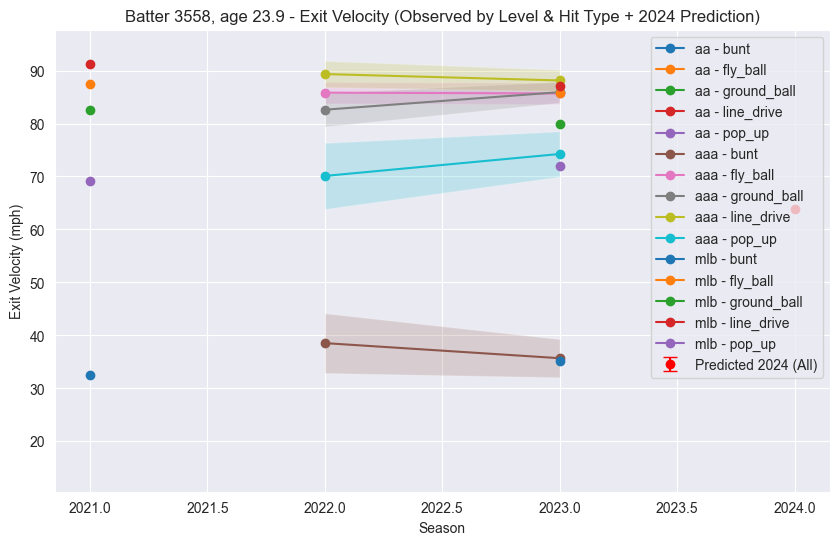

 ====================== Low ELO score BATTERS 1355


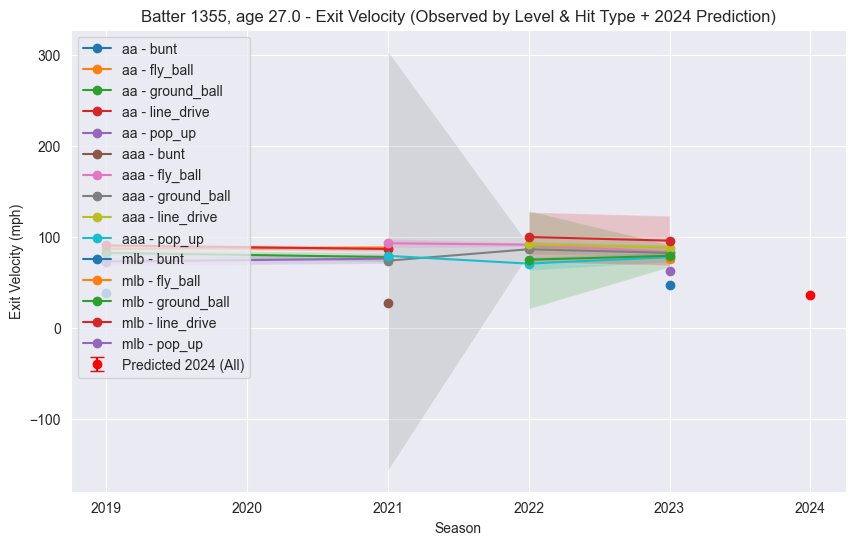

 ====================== Low ELO score BATTERS 2106


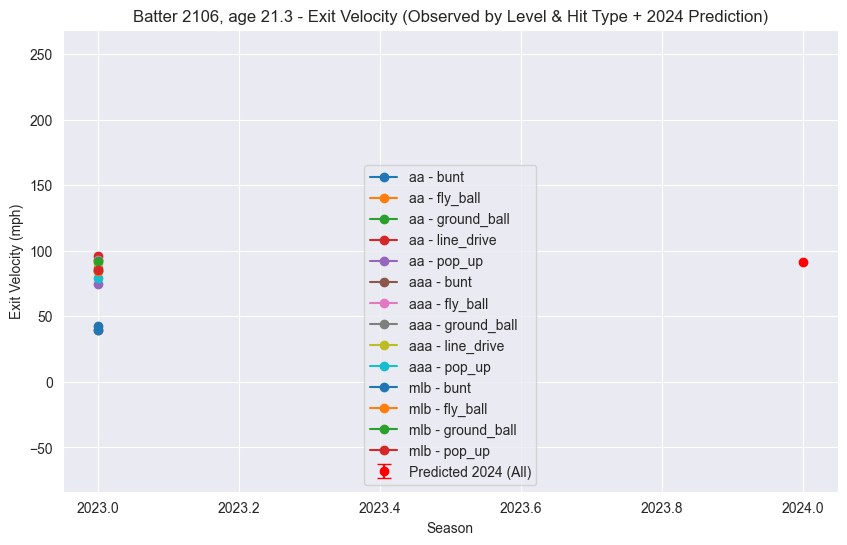

 ====================== Low ELO score BATTERS 3592
single positional indexer is out-of-bounds


In [486]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

#I will take an example of top batters as per the ELO score I did earlier, to evaluate its predicted exit_velo under this model
top_batters = [2725, 3329,2441,2334]
example_batters = [2432,3814,3562,798,3798]
low_perf_batters = [1685,3590, 3558, 1355, 2106, 3592]
preds = df_out[df_out['batter_id'].isin(top_batters+example_batters+low_perf_batters)]


# ---- observed + prediction summary ----
def make_summary_with_prediction(df, batter_id, preds):

    df_batter = df[df['batter_id'] == batter_id]
    # Group by season, level_abbr, and hit_type
    summary = (
        df_batter.groupby(['season', 'level_abbr', 'hit_type'])['exit_velo']
        .agg(['mean', 'count', 'std'])
        .reset_index()
    )

    # Compute CI for observed
    confidence = 0.95
    summary['sem'] = summary['std'] / np.sqrt(summary['count'])
    ci_bounds = stats.t.ppf((1 + confidence) / 2., summary['count'] - 1)
    summary['ci'] = summary['sem'] * ci_bounds
    summary['lower'] = summary['mean'] - summary['ci']
    summary['upper'] = summary['mean'] + summary['ci']

    # Add prediction row — note: no hit_type split in preds, so leave NaN or "All"
    pred = preds.loc[preds['batter_id'] == batter_id].iloc[0]
    pred_row = {
        "season": 2024,
        "level_abbr": "Predicted",
        "hit_type": "All",
        "mean": pred['forecast'],
        "count": np.nan,
        "std": np.nan,
    }
    summary = pd.concat([summary, pd.DataFrame([pred_row])], ignore_index=True)

    return summary


def plot_batter(df, batter_id, preds):
    summary = make_summary_with_prediction(df, batter_id, preds)

    plt.figure(figsize=(10,6))

    # Loop over level_abbr and hit_type
    for (lvl, hit), grp in summary.groupby(["level_abbr", "hit_type"]):
        if grp['season'].max() == 2024 and lvl == "Predicted":
            # Predicted row in red
            plt.errorbar(grp['season'], grp['mean'],
                         yerr=grp['ci'], fmt='o', color='red', capsize=5,
                         label=f"Predicted 2024 ({hit})")
            plt.fill_between(grp['season'], grp['lower'], grp['upper'], color='red', alpha=0.2)
        else:
            # Observed in blue variations
            plt.plot(grp['season'], grp['mean'], marker='o', label=f"{lvl} - {hit}")
            plt.fill_between(grp['season'], grp['lower'], grp['upper'], alpha=0.2)

    plt.xlabel("Season")
    plt.ylabel("Exit Velocity (mph)")
    plt.title(f"Batter {batter_id}, age {df[df['batter_id']==batter_id].age.max()} - Exit Velocity (Observed by Level & Hit Type + 2024 Prediction)")
    plt.legend()
    plt.show()


for batter_id in top_batters+example_batters+low_perf_batters:
    try:
        if batter_id in low_perf_batters:
            print(f" ====================== Low ELO score BATTERS {batter_id}")
        elif batter_id in top_batters:
            print(f" ====================== TOP BATTERS {batter_id}")
        else:
            print(f" ====================== Example BATTERS {batter_id}")
        plot_batter(df, batter_id, preds)
    except Exception as e:
        print(e)